In [1]:
# Parameters
frequency = "1d"


Cargo los datos

In [2]:
import numpy as np
import pandas as pd
from pylab import plt, mpl
import os
import papermill as pm

# Frecuencia obtenida desde el main
try:
    print(f"Frecuencia recibida desde papermill: {frequency}")
except NameError:
    print(f"No se recibió 'frequency'.")

# Cargar los datos para esta frecuencia de un archivo creado por el main
file_name = f"processed_data_{frequency}_WEMH.csv"
data = pd.read_csv(file_name, index_col='timestamp')
data

Frecuencia recibida desde papermill: 1d


,BTCUSDT_1d,ETHUSDT_1d,XRPUSDT_1d,BNBUSDT_1d,SOLUSDT_1d,ADAUSDT_1d,TRXUSDT_1d,LINKUSDT_1d,AVAXUSDT_1d
timestamp,,,,,,,,,
2020-09-22,10529.61,344.21,0.23302,24.0468,2.9082,0.08146,0.02499,8.7401,5.3193
2020-09-23,10241.46,320.72,0.22164,22.8331,2.8548,0.07663,0.02486,7.6364,3.5350
2020-09-24,10736.32,348.97,0.23276,24.5745,3.1433,0.08254,0.02625,9.8700,4.6411
2020-09-25,10686.67,351.92,0.24154,24.6924,3.1937,0.09693,0.02714,10.7279,4.7134
2020-09-26,10728.60,353.92,0.24153,26.1998,3.1287,0.09547,0.02718,10.3169,4.5200
...,...,...,...,...,...,...,...,...,...
2024-12-28,95300.00,3404.00,2.18430,722.1300,195.5000,0.88950,0.25840,21.9900,37.7400
2024-12-29,93738.20,3356.48,2.09420,694.7100,189.9400,0.85900,0.25780,20.9600,35.8400
2024-12-30,92792.05,3361.84,2.05870,705.3600,191.3800,0.86150,0.25340,20.5800,35.9700


Función para guardar los datos. Hace un archivo por cada frecuencia. Guarda en cada línea el modelo que se ha empleado, el activo, accuracy e in/out-sample.

In [3]:
def save_results(model, ric, acc, sample, frequency=frequency):
    # Verificar si el archivo ya existe
    file_name = f'accuracy_results_{frequency}_WEMH.csv'

    # Si el archivo existe, leer los datos previos, si no, crear un nuevo DataFrame vacío
    if os.path.exists(file_name):
        df_results = pd.read_csv(file_name)
    else:
        df_results = pd.DataFrame(columns=['Model', 'Asset', 'Accuracy', 'IN/OUT Sample'])

    # Agregar la nueva fila con los resultados
    new_row = pd.DataFrame([[model, ric, acc, sample]], columns=['Model', 'Asset', 'Accuracy', 'IN/OUT Sample'])
    df_results = pd.concat([df_results, new_row], ignore_index=True)

    # Guardar los resultados acumulados
    df_results.to_csv(file_name, index=False) 

Representación de los datos

C:\Users\raque\AppData\Local\Temp\ipykernel_43068\1561802692.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


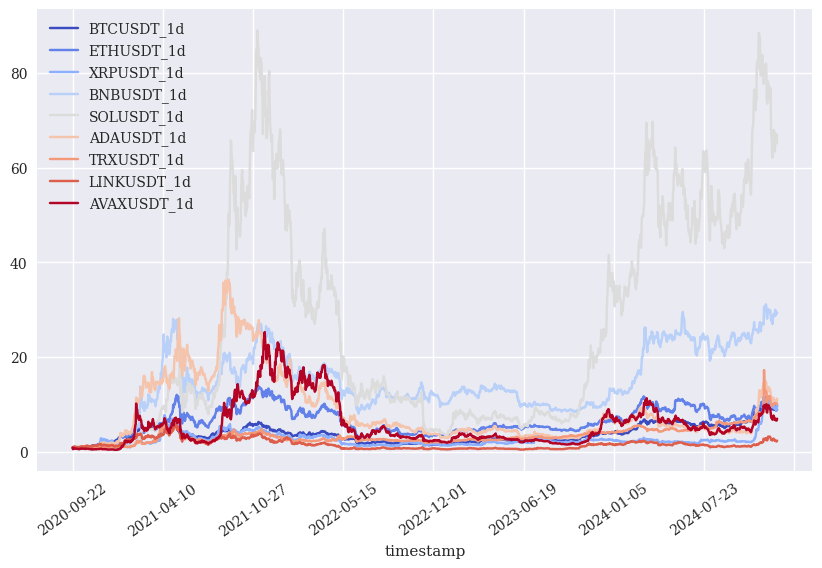

In [4]:
plt.style.use('seaborn')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
np.set_printoptions(suppress=True, precision=4)
(data / data.iloc[0]).plot(figsize=(10, 6), cmap='coolwarm')
plt.xticks(rotation=35)
plt.show()

Retardamos los datos para crear los lags de cada instante de tiempo

In [5]:
lags = 7

def add_lags(data, ric, lags):
    cols = []
    df = pd.DataFrame(data[ric])
    for lag in range(1, lags + 1):
        col = 'lag_{}'.format(lag)
        df[col] = df[ric].shift(lag)
        cols.append(col)
    return df, cols

dfs = {}
for sym in data.columns:
    df, cols = add_lags(data, sym, lags) 
    dfs[sym] = df

dfs[sym].head(7)

,AVAXUSDT_1d,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
timestamp,,,,,,,,
2020-09-22,5.3193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-23,3.5350,5.3193,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-24,4.6411,3.5350,5.3193,NaN,NaN,NaN,NaN,NaN
2020-09-25,4.7134,4.6411,3.5350,5.3193,NaN,NaN,NaN,NaN
2020-09-26,4.5200,4.7134,4.6411,3.5350,5.3193,NaN,NaN,NaN
2020-09-27,4.6484,4.5200,4.7134,4.6411,3.5350,5.3193,NaN,NaN
2020-09-28,4.2021,4.6484,4.5200,4.7134,4.6411,3.5350,5.3193,NaN


In [6]:
# Modificación del tipo a numérico
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df[sym] = pd.to_numeric(df[sym], errors='coerce')
print(dfs[sym])


            AVAXUSDT_1d    lag_1    lag_2    lag_3    lag_4  lag_5  lag_6  \
timestamp                                                                   
2020-09-22       5.3193      NaN      NaN      NaN      NaN    NaN    NaN   
2020-09-23       3.5350   5.3193      NaN      NaN      NaN    NaN    NaN   
2020-09-24       4.6411   3.5350   5.3193      NaN      NaN    NaN    NaN   
2020-09-25       4.7134   4.6411   3.5350   5.3193      NaN    NaN    NaN   
2020-09-26       4.5200   4.7134   4.6411   3.5350   5.3193    NaN    NaN   
...                 ...      ...      ...      ...      ...    ...    ...   
2024-12-28      37.7400  36.5600  37.3300  40.2500  41.2500  39.11  36.57   
2024-12-29      35.8400  37.7400  36.5600  37.3300  40.2500  41.25  39.11   
2024-12-30      35.9700  35.8400  37.7400  36.5600  37.3300  40.25  41.25   
2024-12-31      35.7100  35.9700  35.8400  37.7400  36.5600  37.33  40.25   
2025-01-01      37.7800  35.7100  35.9700  35.8400  37.7400  36.56  37.33   

Se aplica regresión lineal y se muestran los pesos que se le dan a cada lag para hacer la predicción.
Como se puede observar el valor más importante para la predicción es el lag 1, el precio de ayer.

In [7]:
regs = {}
for sym in data.columns:
    df = dfs[sym].dropna()
    reg = np.linalg.lstsq(df[cols], df[sym], rcond=-1)[0]
    regs[sym] = reg
rega = np.stack(tuple(regs.values()))
regd = pd.DataFrame(rega, columns=cols, index=data.columns)
regd

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
BTCUSDT_1d,0.963579,0.051710,-0.016452,0.038172,-0.015458,-0.046616,0.025943
ETHUSDT_1d,0.937319,0.079994,0.016990,-0.008610,-0.077097,0.114141,-0.063020
XRPUSDT_1d,1.005108,-0.030182,0.018919,0.058461,-0.049506,0.028862,-0.030995
BNBUSDT_1d,0.892671,0.177353,-0.024347,-0.041997,-0.088190,0.114010,-0.029227
SOLUSDT_1d,0.996845,0.024929,-0.000926,0.037465,-0.140719,0.108975,-0.026744
ADAUSDT_1d,0.920155,0.082931,-0.075798,0.112649,-0.072737,0.047607,-0.015942
TRXUSDT_1d,0.728082,0.164612,0.072033,0.042688,0.033091,-0.159391,0.120445
LINKUSDT_1d,0.860823,0.176857,-0.059342,0.080943,-0.167058,0.111541,-0.005172
AVAXUSDT_1d,0.992663,0.019910,0.046511,-0.126066,0.013477,0.138109,-0.086543


Observamos que los lags están muy relacionados por lo que todos nos aportan más o menos la misma información.

In [8]:
dfs[sym].corr()

,AVAXUSDT_1d,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
AVAXUSDT_1d,1.000000,0.994475,0.989081,0.983646,0.977476,0.972035,0.967159,0.961291
lag_1,0.994475,1.000000,0.994477,0.989083,0.983647,0.977475,0.972035,0.967158
lag_2,0.989081,0.994477,1.000000,0.994477,0.989083,0.983649,0.977475,0.972036
lag_3,0.983646,0.989083,0.994477,1.000000,0.994476,0.989084,0.983649,0.977475
lag_4,0.977476,0.983647,0.989083,0.994476,1.000000,0.994478,0.989084,0.983650
lag_5,0.972035,0.977475,0.983649,0.989084,0.994478,1.000000,0.994479,0.989083
lag_6,0.967159,0.972035,0.977475,0.983649,0.989084,0.994479,1.000000,0.994479
lag_7,0.961291,0.967158,0.972036,0.977475,0.983650,0.989083,0.994479,1.000000


Hacemos un test de Augmented Dickey-Fuller para comprobar la estacionariedad de los datos. 
Como el primer valor es mayor que todos los valores de disintos niveles de confianza no podemos asegurar que la serie sea estacionaria.

In [9]:
from statsmodels.tsa.stattools import adfuller
adfuller(data[sym].dropna())

(-2.3798529586157846,
 0.14750368541046088,
 9,
 1553,
 {'1%': -3.4345677345088688,
  '5%': -2.8634028737525887,
  '10%': -2.5677617635268795},
 7355.073350800532)

Ahora calculamos los retornos logaritmicos para poder hacer una aprendizaje con una característica. Intentando que esta sea estacionaria al contrario que los precios tal cual. Normalizamos los retornos y mostramos los retornos retardados.

C:\Users\raque\AppData\Local\Temp\ipykernel_43068\1388203415.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


<Axes: xlabel='timestamp'>

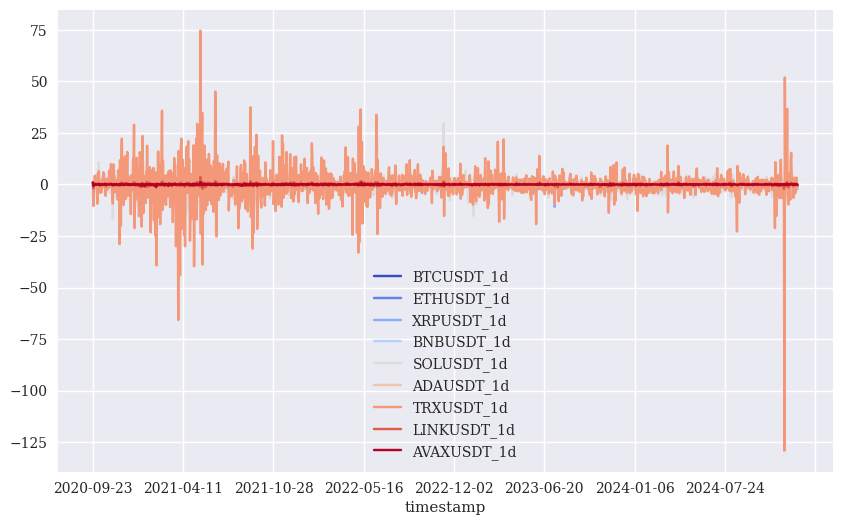

In [10]:
rets = np.log(data / data.shift(1))
rets.dropna(inplace=True)
plt.style.use('seaborn')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
np.set_printoptions(suppress=True, precision=4)
(rets / rets.iloc[0]).plot(figsize=(10, 6), cmap='coolwarm')

In [11]:
dfs = {}
for sym in data:
    df, cols = add_lags(rets, sym, lags)
    mu, std = df[cols].mean(), df[cols].std() 
    df[cols] = (df[cols] - mu) / std
    dfs[sym] = df.dropna()

dfs[sym].head() 


,AVAXUSDT_1d,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
timestamp,,,,,,,,
2020-09-30,0.044855,-0.252776,-1.588377,0.416340,-0.670663,0.220936,4.209081,-6.368076
2020-10-01,-0.042298,0.678626,-0.252781,-1.587845,0.415769,-0.670192,0.220653,4.208879
2020-10-02,-0.059187,-0.676792,0.678328,-0.252676,-1.588207,0.415970,-0.670222,0.219917
2020-10-03,0.026565,-0.939467,-0.676663,0.678134,-0.253177,-1.587507,0.415631,-0.671077
2020-10-04,-0.013232,0.394169,-0.939256,-0.676423,0.677536,-0.252810,-1.587277,0.414922


Los retornos sí son estacionarios.

In [12]:
adfuller(dfs[sym]['lag_1']) 


(-20.560339857389987,
 0.0,
 2,
 1552,
 {'1%': -3.43457045663604,
  '5%': -2.8634040752034995,
  '10%': -2.567762403300696},
 4287.2789301869325)

Y no están correlados.

In [13]:
dfs[sym].corr()

,AVAXUSDT_1d,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
AVAXUSDT_1d,1.000000,0.008095,0.049750,0.063433,0.028768,-0.001018,0.045688,0.028242
lag_1,0.008095,1.000000,0.008438,0.049667,0.064036,0.028469,-0.001529,0.046853
lag_2,0.049750,0.008438,1.000000,0.007993,0.050268,0.063795,0.023810,0.005022
lag_3,0.063433,0.049667,0.007993,1.000000,0.007827,0.050318,0.064586,0.021804
lag_4,0.028768,0.064036,0.050268,0.007827,1.000000,0.007990,0.047964,0.065934
lag_5,-0.001018,0.028469,0.063795,0.050318,0.007990,1.000000,0.008665,0.046812
lag_6,0.045688,-0.001529,0.023810,0.064586,0.047964,0.008665,1.000000,-0.009229
lag_7,0.028242,0.046853,0.005022,0.021804,0.065934,0.046812,-0.009229,1.000000


Predicciones sin train split, probablemente sobreajustadas.

In [14]:
from sklearn.metrics import accuracy_score

for sym in data:
    df = dfs[sym].dropna()
    reg = np.linalg.lstsq(df[cols], df[sym], rcond=-1)[0]
    pred = np.dot(df[cols], reg)
    acc = accuracy_score(np.sign(df[sym]), np.sign(pred))
    print(f'OLS | {sym:10s} | acc={acc:.4f}')
    save_results('OLS', sym, acc, "IN-SAMPLE")

OLS | BTCUSDT_1d | acc=0.5061
OLS | ETHUSDT_1d | acc=0.5190
OLS | XRPUSDT_1d | acc=0.5312
OLS | BNBUSDT_1d | acc=0.5125
OLS | SOLUSDT_1d | acc=0.5016
OLS | ADAUSDT_1d | acc=0.5113
OLS | TRXUSDT_1d | acc=0.5267
OLS | LINKUSDT_1d | acc=0.5331
OLS | AVAXUSDT_1d | acc=0.5100


C:\Users\raque\AppData\Local\Temp\ipykernel_43068\1535030461.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_row], ignore_index=True)


In [15]:
from sklearn.neural_network import MLPRegressor
for sym in data.columns:
    df = dfs[sym].dropna()
    model = MLPRegressor(hidden_layer_sizes=[512],
                        random_state=100,
                        max_iter=1000,
                        early_stopping=True,
                        validation_fraction=0.15,
                        shuffle=False)
    model.fit(df[cols], df[sym])
    pred = model.predict(df[cols])
    acc = accuracy_score(np.sign(df[sym]), np.sign(pred))
    print(f'MLP | {sym:10s} | acc={acc:.4f}')
    save_results('MLP', sym, acc, "IN-SAMPLE")

MLP | BTCUSDT_1d | acc=0.6109


MLP | ETHUSDT_1d | acc=0.6039


MLP | XRPUSDT_1d | acc=0.5717


MLP | BNBUSDT_1d | acc=0.5460


MLP | SOLUSDT_1d | acc=0.6399


MLP | ADAUSDT_1d | acc=0.5331


MLP | TRXUSDT_1d | acc=0.5498


MLP | LINKUSDT_1d | acc=0.5814


MLP | AVAXUSDT_1d | acc=0.5196


Ahora entrenamos con unos datos y testeamos con otros (80% entrenamiento, 20% test).

In [16]:
split = int(len(dfs[sym]) * 0.8)
for sym in data.columns:
    df = dfs[sym].dropna()
    train = df.iloc[:split]
    reg = np.linalg.lstsq(train[cols], train[sym], rcond=-1)[0]
    test = df.iloc[split:]
    pred = np.dot(test[cols], reg)
    acc = accuracy_score(np.sign(test[sym]), np.sign(pred))
    print(f'OLS | {sym:10s} | acc={acc:.4f}')
    save_results('OLS', sym, acc, "OUT-SAMPLE")

OLS | BTCUSDT_1d | acc=0.4823
OLS | ETHUSDT_1d | acc=0.5080
OLS | XRPUSDT_1d | acc=0.5177
OLS | BNBUSDT_1d | acc=0.4920
OLS | SOLUSDT_1d | acc=0.4630
OLS | ADAUSDT_1d | acc=0.4662
OLS | TRXUSDT_1d | acc=0.4759
OLS | LINKUSDT_1d | acc=0.5241
OLS | AVAXUSDT_1d | acc=0.4695


In [17]:
for sym in data.columns:
    df = dfs[sym].dropna()
    train = df.iloc[:split]
    model = MLPRegressor(hidden_layer_sizes=[512],
                        random_state=100,
                        max_iter=1000,
                        early_stopping=True,
                        validation_fraction=0.15,
                        shuffle=False)
    model.fit(train[cols], train[sym])
    test = df.iloc[split:]
    pred = model.predict(test[cols])
    acc = accuracy_score(np.sign(test[sym]), np.sign(pred))
    print(f'MLP | {sym:10s} | acc={acc:.4f}')
    save_results('MLP', sym, acc, "OUT-SAMPLE")

MLP | BTCUSDT_1d | acc=0.4791


MLP | ETHUSDT_1d | acc=0.4952


MLP | XRPUSDT_1d | acc=0.5241


MLP | BNBUSDT_1d | acc=0.4855


MLP | SOLUSDT_1d | acc=0.5338


MLP | ADAUSDT_1d | acc=0.5531


MLP | TRXUSDT_1d | acc=0.5113


MLP | LINKUSDT_1d | acc=0.5177


MLP | AVAXUSDT_1d | acc=0.5016


In [18]:
import tensorflow as tf
from keras.layers import Dense
from keras.models import Sequential

np.random.seed(100)
tf.random.set_seed(100)

def create_model(problem='regression'):
    model = Sequential()
    model.add(Dense(512, input_dim=len(cols),
                    activation='relu'))
    if problem == 'regression':
        model.add(Dense(1, activation='linear'))
        model.compile(loss='mse', optimizer='adam')
    else:
        model.add(Dense(1, activation='sigmoid'))
        model.compile(loss='binary_crossentropy', optimizer='adam')
    return model


for sym in data.columns[:]:
    df = dfs[sym].dropna()
    train = df.iloc[:split]
    test = df.iloc[split:]
    model = create_model()
    model.fit(train[cols], train[sym], epochs=25, verbose=False)
    pred = model.predict(test[cols])
    acc = accuracy_score(np.sign(test[sym]), np.sign(pred))
    print(f'DNN | {sym:10s} | acc={acc:.4f}')
    save_results('DNN', sym, acc, "OUT-SAMPLE")

C:\Users\raque\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


DNN | BTCUSDT_1d | acc=0.4887


C:\Users\raque\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

DNN | LINKUSDT_1d | acc=0.4887


C:\Users\raque\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


DNN | AVAXUSDT_1d | acc=0.5241


Como podemos ver los resultados no son muy esperanzadores por lo que podemos asumir que los mercados son eficientes al menos en la forma debil. Es decir que no es posible sacar beneficios utilizando unicamente los valores pasados de las acciones. 